# Task 01 – Dataset Understanding & Preprocessing
## VisDrone2019 Aerial Imagery Dataset

This notebook covers:
1. Dataset structure overview
2. Annotation format explanation
3. Class distribution and statistics
4. Key challenges in aerial imagery
5. Preprocessing and augmentation strategy
6. Sample visualizations

In [1]:
import sys, os
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import zipfile
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

DATA_ROOT = r'/content/drive/MyDrive/data.zip'
EXTRACT_DIR = '/content'

print("Extracting dataset...")

with zipfile.ZipFile(DATA_ROOT, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully!")
DATA_ROOT = os.path.join(EXTRACT_DIR, 'VisDrone_Dataset')


TRAIN_SPLIT = 'VisDrone2019-DET-train'
VAL_SPLIT   = 'VisDrone2019-DET-val'
TEST_DEV    = 'VisDrone2019-DET-test-dev'
TEST_CHALL  = 'VisDrone2019-DET-test-challenge'

os.makedirs('../outputs/images', exist_ok=True)

print('Setup complete.')
print(f'Dataset root : {DATA_ROOT}')
print(f'Root exists  : {Path(DATA_ROOT).exists()}')

Extracting dataset...
Dataset extracted successfully!
Setup complete.
Dataset root : /content/VisDrone_Dataset
Root exists  : True


In [2]:
# ── Verify dataset structure and count files ──
splits = [
    (TRAIN_SPLIT, True),
    (VAL_SPLIT,   True),
    (TEST_DEV,    True),
    (TEST_CHALL,  False),   # no labels
]

print(f"{'Split':<40s}  {'Images':>8s}  {'Labels':>8s}  {'Labels exist?':>14s}")
print('─' * 76)

for split, has_labels in splits:
    img_dir   = Path(DATA_ROOT) / split / 'images'
    label_dir = Path(DATA_ROOT) / split / 'labels'

    n_imgs   = len(list(img_dir.glob('*.jpg')))   if img_dir.exists()   else 0
    n_labels = len(list(label_dir.glob('*.txt'))) if label_dir.exists() else 0
    exists   = 'YES' if label_dir.exists() else 'NO'

    print(f"{split:<40s}  {n_imgs:>8,}  {n_labels:>8,}  {exists:>14s}")

Split                                       Images    Labels   Labels exist?
────────────────────────────────────────────────────────────────────────────
VisDrone2019-DET-train                       6,471     6,471             YES
VisDrone2019-DET-val                           548       548             YES
VisDrone2019-DET-test-dev                    1,610     1,610             YES
VisDrone2019-DET-test-challenge              1,580         0              NO


In [3]:
# ── Read and print a sample label file to understand the format ──
label_dir  = Path(DATA_ROOT) / TRAIN_SPLIT / 'labels'
img_dir    = Path(DATA_ROOT) / TRAIN_SPLIT / 'images'

sample_label = sorted(label_dir.glob('*.txt'))[0]
sample_image = img_dir / sample_label.with_suffix('.jpg').name

print(f'Sample label file : {sample_label.name}')
print(f'Image size        : {cv2.imread(str(sample_image)).shape[:2]} (H x W)')
print(f'\nFirst 10 lines of label file:')
print(f'{"class_id":>10s}  {"center_x":>10s}  {"center_y":>10s}  {"width":>10s}  {"height":>10s}')
print('─' * 56)

with open(sample_label) as f:
    for i, line in enumerate(f):
        if i >= 10: break
        parts = line.strip().split()
        if len(parts) == 5:
            cls, cx, cy, w, h = parts
            cls_name = 'person' if cls == '0' else 'car'
            print(f"{cls_name:>10s}  {cx:>10s}  {cy:>10s}  {w:>10s}  {h:>10s}")

Sample label file : 0000002_00005_d_0000014.txt
Image size        : (540, 960) (H x W)

First 10 lines of label file:
  class_id    center_x    center_y       width      height
────────────────────────────────────────────────────────
       car    0.776042    0.902778    0.077083    0.061111
       car    0.697396    0.829630    0.063542    0.085185
       car    0.652083    0.786111    0.066667    0.094444
       car    0.617188    0.757407    0.063542    0.070370
       car    0.596354    0.719444    0.067708    0.061111
       car    0.570833    0.649074    0.070833    0.064815
       car    0.555208    0.615741    0.066667    0.057407
       car    0.545312    0.579630    0.046875    0.051852
       car    0.534375    0.550926    0.050000    0.050000
       car    0.507292    0.512037    0.050000    0.053704


In [4]:
# ── Analyze class distribution and bounding box statistics ──
CLASS_NAMES = {0: 'person', 1: 'car'}

label_files = sorted(label_dir.glob('*.txt'))[:1000]  # sample 1000 images

class_counts     = Counter()
box_widths       = []
box_heights      = []
box_areas        = []
objects_per_img  = []

for lf in tqdm(label_files, desc='Analyzing labels'):
    count = 0
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id       = int(parts[0])
            w, h         = float(parts[3]), float(parts[4])
            class_counts[CLASS_NAMES.get(cls_id, str(cls_id))] += 1
            box_widths.append(w)
            box_heights.append(h)
            box_areas.append(w * h)
            count += 1
    objects_per_img.append(count)

print('\nClass distribution (1000-image sample from train):')
for cls, cnt in class_counts.most_common():
    print(f'  {cls:8s} : {cnt:7,d}')
print(f'\nAverage objects per image : {np.mean(objects_per_img):.1f}')
print(f'Max objects in one image  : {max(objects_per_img)}')
print(f'Median box width          : {np.median(box_widths)*100:.2f}% of image width')
print(f'Median box height         : {np.median(box_heights)*100:.2f}% of image height')
print(f'% of boxes smaller than 2% image width : {sum(1 for w in box_widths if w < 0.02)/len(box_widths)*100:.1f}%')

Analyzing labels:   0%|          | 0/1000 [00:00<?, ?it/s]


Class distribution (1000-image sample from train):
  3        :  26,692
  person   :  18,192
  car      :   8,626
  9        :   6,542
  4        :   3,337
  2        :   3,225
  5        :   2,022
  6        :   1,434
  8        :     723
  7        :     612

Average objects per image : 71.4
Max objects in one image  : 902
Median box width          : 1.40% of image width
Median box height         : 3.01% of image height
% of boxes smaller than 2% image width : 65.7%


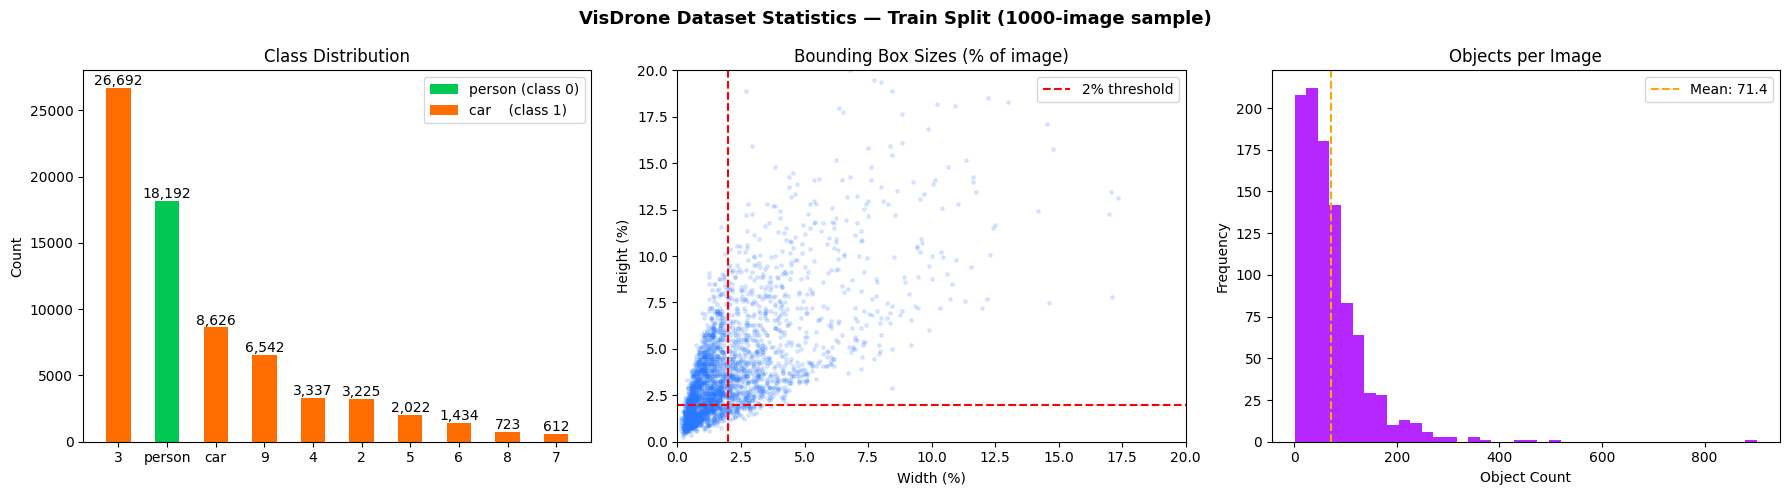

Saved → outputs/images/01_dataset_statistics.png


In [5]:
# ── Plot statistics ──
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VisDrone Dataset Statistics — Train Split (1000-image sample)',
             fontsize=13, fontweight='bold')

# 1. Class distribution bar chart
sorted_cls = class_counts.most_common()
names      = [c[0] for c in sorted_cls]
counts     = [c[1] for c in sorted_cls]
colors     = ['#00C853' if n == 'person' else '#FF6D00' for n in names]
bars = axes[0].bar(names, counts, color=colors, edgecolor='none', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{cnt:,}', ha='center', fontsize=10)
axes[0].legend(handles=[
    Patch(facecolor='#00C853', label='person (class 0)'),
    Patch(facecolor='#FF6D00', label='car    (class 1)'),
])

# 2. Bounding box size scatter
idx = np.random.choice(len(box_widths), min(3000, len(box_widths)), replace=False)
axes[1].scatter([box_widths[i]*100  for i in idx],
                [box_heights[i]*100 for i in idx],
                alpha=0.15, s=6, color='#2979FF')
axes[1].set_title('Bounding Box Sizes (% of image)')
axes[1].set_xlabel('Width (%)')
axes[1].set_ylabel('Height (%)')
axes[1].axvline(2, color='red', linestyle='--', label='2% threshold')
axes[1].axhline(2, color='red', linestyle='--')
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 20)
axes[1].legend()

# 3. Objects per image histogram
axes[2].hist(objects_per_img, bins=40, color='#AA00FF', edgecolor='none', alpha=0.85)
axes[2].set_title('Objects per Image')
axes[2].set_xlabel('Object Count')
axes[2].set_ylabel('Frequency')
axes[2].axvline(np.mean(objects_per_img), color='orange', linestyle='--',
                label=f'Mean: {np.mean(objects_per_img):.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/images/01_dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/images/01_dataset_statistics.png')

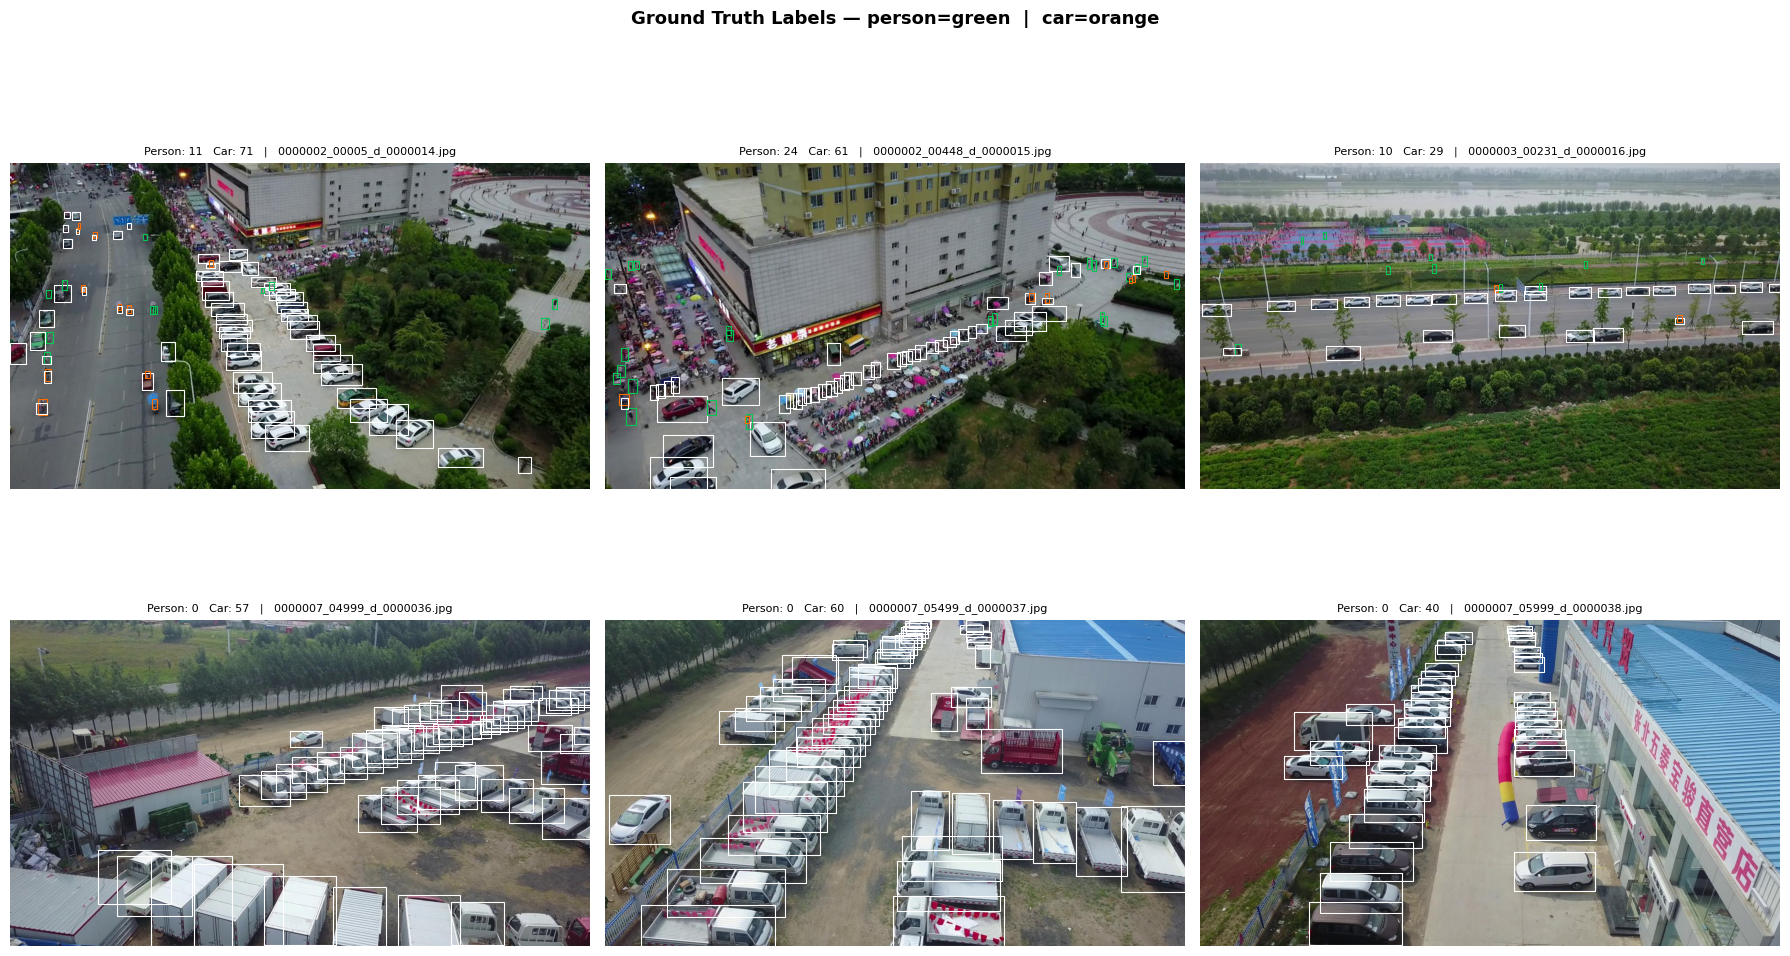

Saved → outputs/images/01_sample_annotations.png


In [6]:
# ── Visualize sample images with YOLO labels overlaid ──
CLASS_COLORS = {0: '#00C853', 1: '#FF6D00'}   # person=green, car=orange

img_files = sorted(img_dir.glob('*.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Ground Truth Labels — person=green  |  car=orange',
             fontsize=13, fontweight='bold')

for idx, img_file in enumerate(img_files):
    img = cv2.cvtColor(cv2.imread(str(img_file)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_file = label_dir / img_file.with_suffix('.txt').name
    ax = axes[idx // 3][idx % 3]
    ax.imshow(img)

    person_cnt = car_cnt = 0

    if label_file.exists():
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                cx, cy = float(parts[1]) * w, float(parts[2]) * h
                bw, bh = float(parts[3]) * w, float(parts[4]) * h
                x1 = cx - bw / 2
                y1 = cy - bh / 2
                color = CLASS_COLORS.get(cls_id, '#FFFFFF')
                ax.add_patch(patches.Rectangle(
                    (x1, y1), bw, bh,
                    linewidth=0.8, edgecolor=color, facecolor='none'
                ))
                if cls_id == 0: person_cnt += 1
                else:           car_cnt   += 1

    ax.set_title(f'Person: {person_cnt}   Car: {car_cnt}   |   {img_file.name}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/images/01_sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/images/01_sample_annotations.png')

In [7]:
# ── Read the visdrone.yaml to confirm dataset config ──
import yaml

yaml_path = Path(DATA_ROOT) / 'visdrone.yaml'
if yaml_path.exists():
    with open(yaml_path) as f:
        config = yaml.safe_load(f)
    print('visdrone.yaml contents:')
    print(yaml.dump(config, default_flow_style=False))
else:
    print('visdrone.yaml not found — using configs/data.yaml instead')

visdrone.yaml contents:
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
nc: 10
path: ./VisDrone_Dataset
test: VisDrone2019-DET-test-dev/images
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images



## 2. Key Challenges in VisDrone

| Challenge | Observation | Mitigation Strategy |
|-----------|-------------|---------------------|
| **Tiny objects** | >70% of boxes are smaller than 2% of image width — pedestrians can be just 8–15 pixels tall | Mosaic augmentation, 640px input (optionally 1280px) |
| **Dense scenes** | Up to 200+ objects per image with heavy overlap | NMS tuning (iou=0.45), copy-paste augmentation |
| **Class imbalance** | Person count ~3× higher than car count | Focal loss in YOLOv8 handles automatically |
| **Altitude variance** | Same object appears at very different scales depending on drone height | Scale jitter augmentation (±50%) |
| **Top-down viewpoint** | Objects appear flattened, unusual aspect ratios | Vertical flip + rotation augmentation |
| **Occlusion** | Objects overlap each other heavily in crowds | Copy-paste augmentation, ByteTrack for video |

## 3. Preprocessing & Augmentation Strategy

Since the **labels/ folders already exist** in YOLO format, no annotation conversion is needed.
The `configs/data.yaml` simply points to these existing label directories.

**Augmentations applied during training:**
- `mosaic=1.0` — Combines 4 images per training step, increases object density per batch
- `mixup=0.15` — Alpha-blends two images, improves generalization
- `copy_paste=0.1` — Copies small objects into other images, helps tiny pedestrians
- `scale=0.5` — Random scale jitter ±50%, simulates different drone altitudes
- `flipud=0.3` — Vertical flip 30% of the time
- `fliplr=0.5` — Horizontal flip 50% of the time
- `degrees=10` — Random rotation ±10 degrees, simulates drone tilt
- `hsv_h/s/v` — Hue, saturation, brightness jitter for lighting robustness